# 06 — Investigation précise du dataset lastfm-1K

On investigue les données AVANT de basculer le POC JEPA dessus, pour trancher deux décisions de
mise en forme (impossible à deviner, à lire dans les données) :

1. **Le grain d'item** : un « item » = un **artiste**, un **track** `(artist, track)`, ou un
   **track par MBID** ? Compromis *densité* (apprenable) vs *précision* (le morceau exact).
2. **Le grain de session** : à quel écart couper une session d'écoute (pour le chunking).

Logique dans `lastfm/src/lastfm_data.py`. Données brutes dans `lastfm/data/raw/` (gitignorées).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()  # = lastfm/
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 20)
from src import lastfm_data as L

N_USERS = 100          # échantillon (fichier trié par user) ; None = tout (lourd)
df = L.load_events(n_users=N_USERS)
print(f'{len(df):,} plays | {df.user.nunique()} users')
df.head()

2,085,155 plays | 100 users


,user,artist,track_mbid,track,ts
0,user_000001,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007,1241478537
1,user_000001,坂本龍一,NaN,Composition 0919 (Live_2009_4_15),1241445250
2,user_000001,坂本龍一,NaN,Mc2 (Live_2009_4_15),1241445124
3,user_000001,坂本龍一,NaN,Hibari (Live_2009_4_15),1241444572
4,user_000001,坂本龍一,NaN,Mc1 (Live_2009_4_15),1241444531


## 1. Qualité & sanité des données

Types, valeurs manquantes, couverture du `track_mbid` (la clé qui perd des events), doublons
exacts, et bornes temporelles. C'est le contrôle qu'on aurait dû faire sur MovieLens dès le début.

In [2]:
print('dtypes:'); print(df.dtypes)
print('\nmanquants (%):'); print((df.isna().mean() * 100).round(2))
print(f'\ncouverture track_mbid : {df.track_mbid.notna().mean():.1%}')
print(f'doublons exacts (user, ts, track) : {df.duplicated(["user","ts","track"]).sum():,}')
print('période :', pd.to_datetime(df.ts.min(), unit='s').date(),
      '->', pd.to_datetime(df.ts.max(), unit='s').date())

dtypes:
user          object
artist        object
track_mbid    object
track         object
ts             int64
dtype: object

manquants (%):
user           0.00
artist         0.00
track_mbid    11.65
track          0.00
ts             0.00
dtype: float64

couverture track_mbid : 88.4%
doublons exacts (user, ts, track) : 0
période : 2005-02-14 -> 2009-06-19


## 2. Volumétrie & activité dans le temps

Richesse par user (events, étalement temporel) et forme de l'activité globale sur le calendrier.
C'est ce qui rend lastfm apte au temporel là où MovieLens ne l'était pas.

events/user : méd 14038  moy 20852
span/user (jours) : méd 979  p10 340  p90 1391


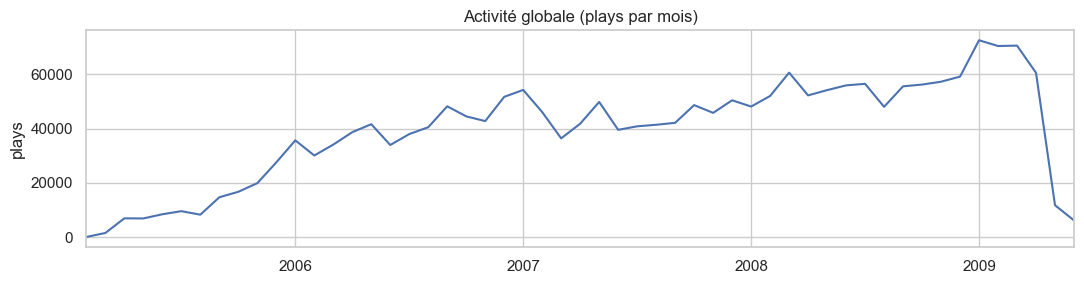

In [3]:
ev = df.groupby('user').size()
span = df.groupby('user').ts.agg(lambda s: (s.max() - s.min()) / 86400)
print(f'events/user : méd {ev.median():.0f}  moy {ev.mean():.0f}')
print(f'span/user (jours) : méd {span.median():.0f}  p10 {span.quantile(.1):.0f}  p90 {span.quantile(.9):.0f}')

ts = pd.to_datetime(df.ts, unit='s')
by_month = ts.dt.to_period('M').value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 3))
by_month.plot(ax=ax, color='#4C72B0')
ax.set_title('Activité globale (plays par mois)'); ax.set_ylabel('plays'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

## 3. Le grain d'item — la décision centrale

Pour chaque grain : taille de catalogue, densité (plays/item), part vue une seule fois
(`%_items_1play`, la queue froide), concentration (`%_events_top1pct`), et couverture.
Puis la distribution des plays en log-log (longue traîne / Zipf), et surtout la **survie au
k-core** : un grain trop fin s'effondre (catalogue non viable pour un modèle).

In [4]:
cat = L.catalog_stats(df)
display(cat.style.format({'plays/item méd.':'{:.0f}','plays/item moy.':'{:.1f}',
    '%_items_1play':'{:.1%}','%_events_top1pct':'{:.1%}','%_events_couverts':'{:.1%}'}))

,grain,n_items,plays/item méd.,plays/item moy.,%_items_1play,%_events_top1pct,%_events_couverts
0,artist,39861,3,52.3,30.4%,45.5%,100.0%
1,track,289971,2,7.2,39.2%,19.9%,100.0%
2,track_mbid,225665,2,8.2,35.5%,19.1%,88.4%


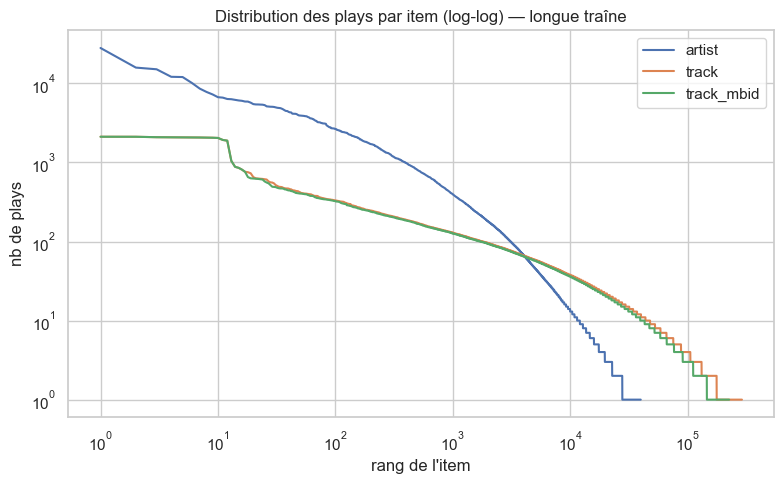

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for gr, c in [('artist', '#4C72B0'), ('track', '#DD8452'), ('track_mbid', '#55A868')]:
    v = np.sort(L.item_key(df, gr).value_counts().values)[::-1]
    ax.loglog(np.arange(1, len(v) + 1), v, label=gr, color=c)
ax.set_xlabel('rang de l\'item'); ax.set_ylabel('nb de plays')
ax.set_title('Distribution des plays par item (log-log) — longue traîne'); ax.legend()
plt.tight_layout(); plt.show()

In [6]:
for gr in L.GRAINS:
    print(f'--- k-core, grain = {gr} ---')
    print(L.kcore_survival(df, gr).to_string(index=False)); print()

--- k-core, grain = artist ---
 k  users  items  paires
 5    100   3926   47008
10     99   1700   32634
20     99    572   17619

--- k-core, grain = track ---
 k  users  items  paires
 5     99  13778  113313
10     99   3407   47811
20     82    358    8540

--- k-core, grain = track_mbid ---
 k  users  items  paires
 5     99  13631  112243
10     99   3390   47565
20     82    354    8451



## 4. Consommation répétée — un signal absent de MovieLens

La musique se réécoute. `repeat_fraction` = part des plays sur un item DÉJÀ écouté par le user.
Un `repeat_fraction` élevé signifie qu'une grosse partie de la « prédiction » est de la
**réécoute** (favoris) — à la fois un signal fort et une baseline à battre (répétition).

In [7]:
rep = pd.DataFrame([L.repeat_stats(df, gr) for gr in L.GRAINS])
display(rep.style.format({'plays':'{:,.0f}','paires_distinctes':'{:,.0f}',
    'repeat_fraction':'{:.1%}','items_distincts/user_méd.':'{:.0f}','unique/total_user_méd.':'{:.2f}'}))

,grain,plays,paires_distinctes,repeat_fraction,items_distincts/user_méd.,unique/total_user_méd.
0,artist,"2,085,155","95,771",95.4%,616,0.06
1,track,"2,085,155","470,007",77.5%,3704,0.27
2,track_mbid,"1,842,321","401,880",78.2%,2936,0.27


## 5. Structure temporelle & sessions

Écarts entre plays consécutifs (l'ordre est-il réel ?) et segmentation en sessions selon le seuil.
Informe le grain de session pour le chunking (contrairement à MovieLens, on attend des centaines
de vraies sessions par user).

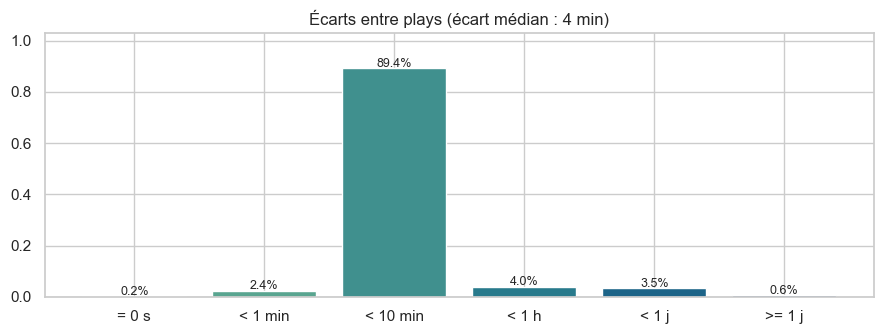

,seuil,tau_s,sessions/user méd.,sessions/user moy.,taille méd.,taille moy.,taille p90
0,20 min,1200,904,1174,9,17.8,40
1,1 h,3600,702,846,12,24.7,55
2,6 h,21600,416,484,24,43.1,95
3,1 jour,86400,120,123,46,169.1,393


In [8]:
tsl = L.user_timestamps(df)
g = L.all_gaps(tsl)
edges = [0, 1, 60, 600, 3600, 86400, np.inf]
labels = ['= 0 s', '< 1 min', '< 10 min', '< 1 h', '< 1 j', '>= 1 j']
frac = [np.mean((g >= edges[i]) & (g < edges[i+1])) for i in range(len(labels))]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(labels, frac, color=sns.color_palette('crest', len(labels)))
for i, f in enumerate(frac): ax.text(i, f + 0.005, f'{f:.1%}', ha='center', fontsize=9)
ax.set_title(f'Écarts entre plays (écart médian : {L.human_seconds(np.median(g))})')
ax.set_ylim(0, max(frac) * 1.15); plt.tight_layout(); plt.show()

display(L.session_size_summary(tsl).style.format({'sessions/user méd.':'{:.0f}',
    'sessions/user moy.':'{:.0f}','taille méd.':'{:.0f}','taille moy.':'{:.1f}','taille p90':'{:.0f}'}))

## 6. Synthèse & décision de grain

*(Chiffres indicatifs d'un run sample=100 users ; relancer avec `N_USERS=None` pour le catalogue complet.)*

**Grain d'item — le compromis, chiffré :**

| Grain | Catalogue | Queue froide (1 play) | k-core=5 | Verdict |
|---|---|---|---|---|
| **artiste** | ~40 k | ~30 % | robuste (~4 k items) | dense, apprenable, mais perd le morceau |
| **track** (artist, track) | ~290 k | ~39 % | ~14 k items, s'effondre à k=20 | précis, capte les replays, mais creux |
| **track_mbid** | ~226 k | ~36 % | idem track − 12 % de couverture | à éviter (perte d'events, doublons MBID) |

**Consommation répétée :** `repeat_fraction` ≈ **95 % au grain artiste**, ~77 % au grain track →
une baseline *répétition* sera FORTE ici ; le modèle devra la battre pour prouver sa valeur.

**Recommandation à discuter :**
- **Démarrer au grain `track` avec un 5-core** : garde la précision morceau (et donc l'ordre
  d'écoute réel + les replays), tout en éliminant la queue froide non-apprenable. C'est le grain
  le plus fidèle à ce qu'on veut modéliser (trajectoire d'écoute).
- **Grain `artiste` en repli / ablation** si le catalogue track reste trop creux à l'entraînement.
- Écarter `track_mbid` (couverture 88 %, doublons d'ID).

**Décisions ouvertes (à trancher ensemble) :** grain retenu · seuil de session pour le chunking ·
cap de longueur par user (les users ont ~13 k events !) · gestion des replays (garder tels quels
vs dédupliquer par session).